In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, DBSCAN

In [9]:
root_path = "/home/stefan/ioai-prep/kits/locala"

seed = 42

In [10]:
df = pd.read_csv(f"{root_path}/transport.csv")
df.head()

,id,vehicle_type,latitude,longitude,timestamp
0,64,3,64.8924,16.4665,2025-12-09 19:26:55
1,657,3,64.8934,16.4681,2025-12-09 21:14:25
2,536,3,64.8922,16.4679,2025-12-09 21:08:41
3,216,3,64.8926,16.4661,2025-12-09 20:00:01
4,156,3,64.9084,16.4446,2025-12-09 21:14:37


# Subtask 1

In [11]:
df["id"].nunique(), len(df)

(663, 2058806)

In [12]:
df["vehicle_type"].nunique()

4

In [13]:
subtask11 = df["id"].nunique()
subtask12 = df["vehicle_type"].nunique()

# Subtask 2

<Axes: xlabel='latitude', ylabel='longitude'>

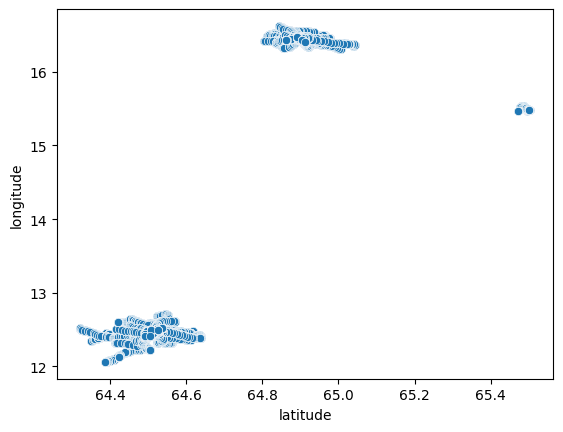

In [ ]:
# from this we can see there are 3 citiesA
sns.scatterplot(x="latitude", y="longitude", data=df)

In [ ]:
vehicle_coords = df.groupby("id")[["latitude", "longitude"]].median().reset_index()
# only store mean coords of each vehile, since each vehicle has multiple entries

clustering = DBSCAN(eps=0.5, min_samples=3, n_jobs=-1)
vehicle_coords["city"] = clustering.fit_predict(
    vehicle_coords[["latitude", "longitude"]]
)

vehicle_coords["city"].value_counts()

city
0    374
1    275
2     14
Name: count, dtype: int64

<Axes: xlabel='latitude', ylabel='longitude'>

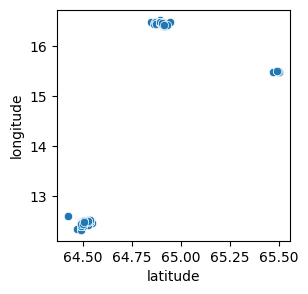

In [ ]:
plt.figure(figsize=(3,3)) 
sns.scatterplot(x="latitude", y="longitude", data=vehicle_coords)

In [ ]:
city_mapping = {
    old: new for new, old in enumerate(sorted(vehicle_coords["city"].unique()))
}
vehicle_coords["city"] = vehicle_coords["city"].map(city_mapping)

subtask2 = vehicle_coords[["id", "city"]]
subtask2.head()

,id,city
0,0,0
1,1,0
2,2,0
3,3,0
4,4,0


# Subtask 3

In [ ]:
type10 = df[df["vehicle_type"] == 10].copy()
type10["hour"] = pd.to_datetime(type10["timestamp"]).dt.hour
type10["hour"].describe()

count    307722.000000
mean         11.950777
std           6.374987
min           0.000000
25%           7.000000
50%          12.000000
75%          17.000000
max          23.000000
Name: hour, dtype: float64

In [ ]:
type10 = type10[(type10["hour"] == 23) | (type10["hour"] < 3)]
len(type10)

28805

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=seed, n_init=10)
type10_coords = type10[["latitude", "longitude"]].copy()
type10_coords["depot"] = kmeans.fit_predict(type10_coords)

depots = type10_coords.groupby("depot")[["latitude", "longitude"]].mean().reset_index(drop=True)

In [ ]:
subtask3 = depots.sort_values("latitude").reset_index(drop=True)
subtask3

,latitude,longitude
0,64.863788,16.433179
1,64.904665,16.440443
2,64.910855,16.401355


# Submission

In [ ]:
def build_df(sid, ans1, ans2):
    if sid != 1:
        return pd.DataFrame(
            {
                "subtaskID": [sid] * len(ans1),
                "Value1": ans1.values,
                "Value2": ans2.values,
            }
        )
    else:
        return pd.DataFrame({"subtaskID": [sid], "Value1": [ans1], "Value2": [ans2]})


subtasks = [
    (1, subtask11, subtask12),
    (2, subtask2["id"], subtask2["city"]),
    (3, subtask3["latitude"], subtask3["longitude"]),
]

submission_df = pd.concat(
    [build_df(sid, ans1, ans2) for sid, ans1, ans2 in subtasks], ignore_index=True
)

In [ ]:
submission_df.head()

,subtaskID,Value1,Value2
0,1,663.0,4.0
1,2,0.0,0.0
2,2,1.0,0.0
3,2,2.0,0.0
4,2,3.0,0.0


In [ ]:
submission_df.to_csv(f"{root_path}/submission.csv", index=False)